In [2]:
import pandas as pd
import numpy as np
import os
import sys

print("Libraries loaded successfully.")
print("Python: ", sys.version)
print("Python executable: ", sys.executable)
print("Pandas: ", pd.__version__)
print("NumPy: ", np.__version__)


Libraries loaded successfully.
Python:  3.12.14 (main, Aug 12 2026, 13:57:54) [Clang 21.0.0 (clang-2100.1.1.101)]
Python executable:  /Users/persisazemsada/Desktop/Projects/Network_IDS/venv/bin/python
Pandas:  3.0.5
NumPy:  2.5.3


In [4]:
DATA_DIR = "../data/raw/MachineLearningCVE"

csv_files = sorted([
    os.path.join(DATA_DIR, file)
    for file in os.listdir(DATA_DIR)
    if file.endswith('.csv')
])

print(f"Number of CSV files: {len(csv_files)}")

for file in csv_files:
    print(os.path.basename(file))

Number of CSV files: 8
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Friday-WorkingHours-Morning.pcap_ISCX.csv
Monday-WorkingHours.pcap_ISCX.csv
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Tuesday-WorkingHours.pcap_ISCX.csv
Wednesday-workingHours.pcap_ISCX.csv


In [6]:
sample_file = csv_files[0]
df_sample = pd.read_csv(sample_file)

print("File: ", os.path.basename(sample_file))
print("Shape: ", df_sample.shape)


File:  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Shape:  (225745, 79)


In [11]:
df_sample.columns = df_sample.columns.str.strip()  # Strip whitespace from column names
print(df_sample.columns.tolist())  # Print the cleaned column names
print(df_sample["Label"].value_counts())  # Print the distribution of the 'Label' column


['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count

In [12]:
print("Shape:", df_sample.shape)
print("\nClass distribution:")
print(df_sample["Label"].value_counts())

Shape: (225745, 79)

Class distribution:
Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64


In [15]:
dataset_info = []

for file in csv_files:
    df = pd.read_csv(file)
    df.columns = df.columns.str.strip()

    dataset_info.append({
        "file": os.path.basename(file),
        "rows": len(df),
        "columns": len(df.columns),
        "classes": df["Label"].nunique(),
        "labels": ", ".join(df["Label"].dropna().astype(str).unique())
    })

    del df  # Free up memory
dataset_info_df = pd.DataFrame(dataset_info)

dataset_info_df


,file,rows,columns,classes,labels
0,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,225745,79,2,"BENIGN, DDoS"
1,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,286467,79,2,"BENIGN, PortScan"
2,Friday-WorkingHours-Morning.pcap_ISCX.csv,191033,79,2,"BENIGN, Bot"
3,Monday-WorkingHours.pcap_ISCX.csv,529918,79,1,BENIGN
4,Thursday-WorkingHours-Afternoon-Infilteration....,288602,79,2,"BENIGN, Infiltration"
5,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,170366,79,4,"BENIGN, Web Attack � Brute Force, Web Attack �..."
6,Tuesday-WorkingHours.pcap_ISCX.csv,445909,79,3,"BENIGN, FTP-Patator, SSH-Patator"
7,Wednesday-workingHours.pcap_ISCX.csv,692703,79,6,"BENIGN, DoS slowloris, DoS Slowhttptest, DoS H..."


In [16]:
for _, row in dataset_info_df.iterrows():
    print("\n" + row["file"])
    print("Rows:", row["rows"])
    print("Classes:", row["classes"])
    print("Labels:", row["labels"])


Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Rows: 225745
Classes: 2
Labels: BENIGN, DDoS

Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Rows: 286467
Classes: 2
Labels: BENIGN, PortScan

Friday-WorkingHours-Morning.pcap_ISCX.csv
Rows: 191033
Classes: 2
Labels: BENIGN, Bot

Monday-WorkingHours.pcap_ISCX.csv
Rows: 529918
Classes: 1
Labels: BENIGN

Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Rows: 288602
Classes: 2
Labels: BENIGN, Infiltration

Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Rows: 170366
Classes: 4
Labels: BENIGN, Web Attack � Brute Force, Web Attack � XSS, Web Attack � Sql Injection

Tuesday-WorkingHours.pcap_ISCX.csv
Rows: 445909
Classes: 3
Labels: BENIGN, FTP-Patator, SSH-Patator

Wednesday-workingHours.pcap_ISCX.csv
Rows: 692703
Classes: 6
Labels: BENIGN, DoS slowloris, DoS Slowhttptest, DoS Hulk, DoS GoldenEye, Heartbleed


In [17]:
print("Missing values:", df_sample.isna().sum().sum())
print("Infinite values:", np.isinf(df_sample.select_dtypes(include=np.number)).sum().sum())

print("Duplicate rows:", df_sample.duplicated().sum())

Missing values: 4
Infinite values: 64
Duplicate rows: 2633


In [21]:
from collections import Counter

all_labels = Counter()

for file in csv_files:
    df = pd.read_csv(
        file,
        usecols=lambda column: column.strip().lstrip("\ufeff") == "Label"
    )
    df.columns = df.columns.str.strip().str.lstrip("\ufeff")
    df["Label"] = df["Label"].astype(str).str.strip()

    all_labels.update(df["Label"].value_counts().to_dict())

    del df

label_distribution = pd.DataFrame(
    all_labels.items(),
    columns=["Label", "Count"]
).sort_values("Count", ascending=False)

label_distribution

print("Total records:", label_distribution["Count"].sum())
print("Total classes:", len(label_distribution))

label_distribution["Percentage"] = (
    label_distribution["Count"]
    / label_distribution["Count"].sum()
    * 100
)

label_distribution

Total records: 2830743
Total classes: 15


,Label,Count,Percentage
1,BENIGN,2273097,80.300366
10,DoS Hulk,231073,8.162981
2,PortScan,158930,5.614427
0,DDoS,128027,4.522735
11,DoS GoldenEye,10293,0.363615
8,FTP-Patator,7938,0.280421
9,SSH-Patator,5897,0.208320
12,DoS slowloris,5796,0.204752
13,DoS Slowhttptest,5499,0.194260
3,Bot,1966,0.069452


In [27]:
label_mapping = {
    "Web Attack � Brute Force": "Web Attack - Brute Force",
    "Web Attack � XSS": "Web Attack - XSS",
    "Web Attack � Sql Injection": "Web Attack - Sql Injection"
}

label_distribution["Label"] = label_distribution["Label"].replace(label_mapping)

label_distribution

,Label,Count,Percentage
1,BENIGN,2273097,80.300366
10,DoS Hulk,231073,8.162981
2,PortScan,158930,5.614427
0,DDoS,128027,4.522735
11,DoS GoldenEye,10293,0.363615
8,FTP-Patator,7938,0.280421
9,SSH-Patator,5897,0.208320
12,DoS slowloris,5796,0.204752
13,DoS Slowhttptest,5499,0.194260
3,Bot,1966,0.069452


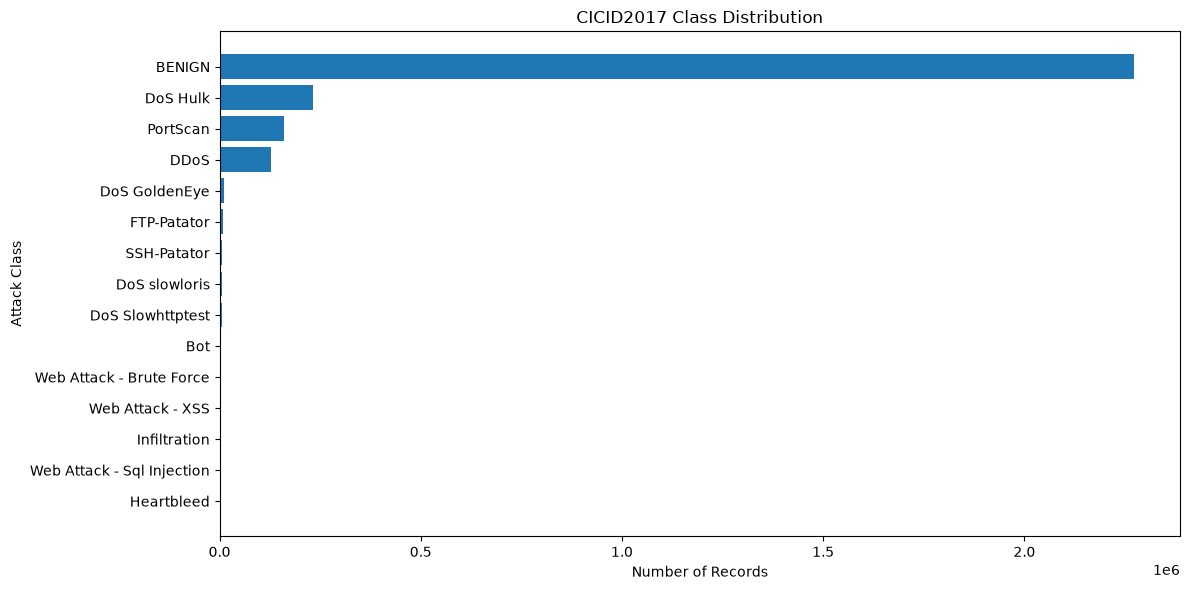

In [28]:
#EDA visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.barh(
    label_distribution["Label"],
    label_distribution["Count"]
)

plt.xlabel("Number of Records")
plt.ylabel("Attack Class")
plt.title("CICID2017 Class Distribution")

plt.gca().invert_yaxis()  # Invert y-axis to have the largest bar on top
plt.tight_layout()
plt.show()

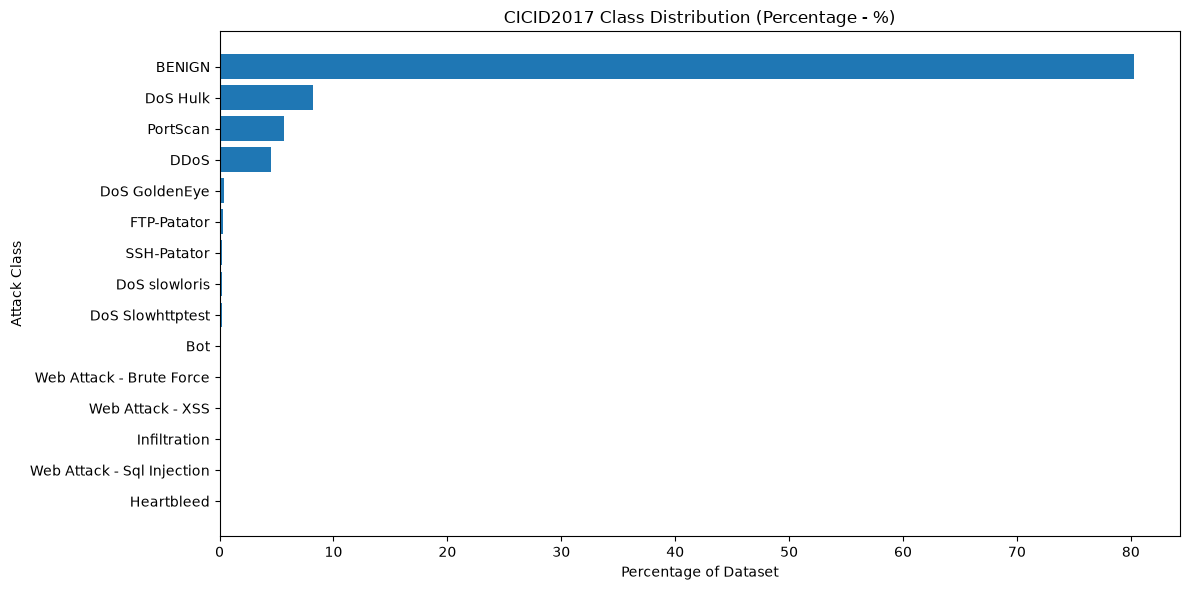

In [29]:
plt.figure(figsize=(12, 6))

plt.barh(
    label_distribution["Label"],
    label_distribution["Percentage"]
)

plt.xlabel("Percentage of Dataset")
plt.ylabel("Attack Class")
plt.title("CICID2017 Class Distribution (Percentage - %)")

plt.gca().invert_yaxis()  # Invert y-axis to have the largest bar on top
plt.tight_layout()
plt.show()

In [33]:
print("Total columns:", len(df_sample.columns))

print("\nNon-numeric columns:")
print(df_sample.select_dtypes(exclude=np.number).columns.tolist())

print("\nNumeric columns:")
print(len(df_sample.select_dtypes(include=np.number).columns))

print("Missing values per column:")
print(df_sample.isna().sum()[df_sample.isna().sum() > 0])

numeric_df = df_sample.select_dtypes(include=np.number)

inf_counts = np.isinf(numeric_df).sum()

print("Columns containing infinity:")
print(inf_counts[inf_counts > 0])

Total columns: 79

Non-numeric columns:
['Label']

Numeric columns:
78
Missing values per column:
Flow Bytes/s    4
dtype: int64
Columns containing infinity:
Flow Bytes/s      30
Flow Packets/s    34
dtype: int64


In [37]:
problematic = df_sample[
    ~np.isfinite(df_sample["Flow Bytes/s"]) |
    ~np.isfinite(df_sample["Flow Packets/s"]) |
    df_sample["Flow Bytes/s"].isna()
]

print("Problematic rows:", len(problematic))

problematic[
    [
        "Flow Duration",
        "Total Length of Fwd Packets",
        "Total Length of Bwd Packets",
        "Flow Bytes/s",
        "Flow Packets/s",
        "Label"
    ]
].head(10)

problematic["Label"].value_counts()

duplicate_rows = df_sample[df_sample.duplicated(keep=False)]

print("Duplicate records:", len(duplicate_rows))

print("\nLabels among duplicate records:")
print(duplicate_rows["Label"].value_counts())

feature_columns = df_sample.select_dtypes(include=np.number).columns

constant_features = [
    col for col in feature_columns
    if df_sample[col].nunique(dropna=False) <= 1
]

print("Constant features:", len(constant_features))
print(constant_features)

Problematic rows: 34
Duplicate records: 3940

Labels among duplicate records:
Label
BENIGN    3920
DDoS        20
Name: count, dtype: int64
Constant features: 10
['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


In [40]:
#full dataset quality analysis
quality_results = []

for file in csv_files:
    df = pd.read_csv(file)
    df.columns = df.columns.str.strip().str.lstrip("\ufeff")

    numeric_columns = df.select_dtypes(include=np.number).columns

    missing = int(df.isna().sum().sum())
    infinite = int(
        np.isinf(df[numeric_columns]).sum().sum()
    )
    duplicates = int(df.duplicated().sum())

    quality_results.append({
        "file": os.path.basename(file),
        "rows": len(df),
        "missing_values": missing,
        "infinite_values": infinite,
        "duplicate_rows": duplicates
    })

    del df

quality_df = pd.DataFrame(quality_results)

quality_df

quality_df.sum(numeric_only=True)

#check constant features acroos the complete dataset
feature_stats = {}

for file in csv_files:
    df = pd.read_csv(file)
    df.columns = df.columns.str.strip().str.lstrip("\ufeff")

    numeric_columns = df.select_dtypes(include=np.number).columns

    for column in numeric_columns:
        series = df[column].replace([np.inf, -np.inf], np.nan)

        current_min = series.min()
        current_max = series.max()

        if column not in feature_stats:
            feature_stats[column] = {
                "min": current_min,
                "max": current_max
            }
        else:
            if pd.notna(current_min):
                if pd.isna(feature_stats[column]["min"]):
                    feature_stats[column]["min"] = current_min
                else:
                    feature_stats[column]["min"] = min(
                        feature_stats[column]["min"],
                        current_min
                    )

            if pd.notna(current_max):
                if pd.isna(feature_stats[column]["max"]):
                    feature_stats[column]["max"] = current_max
                else:
                    feature_stats[column]["max"] = max(
                        feature_stats[column]["max"],
                        current_max
                    )

    del df

feature_stats_df = pd.DataFrame.from_dict(
    feature_stats,
    orient="index"
)

feature_stats_df.index.name = "Feature"

feature_stats_df["is_constant"] = (
    feature_stats_df["min"] == feature_stats_df["max"]
)

feature_stats_df

print("Constant features across all files:")

print(
    feature_stats_df[
        feature_stats_df["is_constant"]
    ]
)

Constant features across all files:
                      min  max  is_constant
Feature                                    
Bwd PSH Flags         0.0  0.0         True
Bwd URG Flags         0.0  0.0         True
Fwd Avg Bytes/Bulk    0.0  0.0         True
Fwd Avg Packets/Bulk  0.0  0.0         True
Fwd Avg Bulk Rate     0.0  0.0         True
Bwd Avg Bytes/Bulk    0.0  0.0         True
Bwd Avg Packets/Bulk  0.0  0.0         True
Bwd Avg Bulk Rate     0.0  0.0         True


In [ ]:
quality_df
#quality_df.sum(numeric_only=True)

,file,rows,missing_values,infinite_values,duplicate_rows
0,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,225745,4,64,2633
1,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,286467,15,727,72353
2,Friday-WorkingHours-Morning.pcap_ISCX.csv,191033,28,216,6888
3,Monday-WorkingHours.pcap_ISCX.csv,529918,64,810,26935
4,Thursday-WorkingHours-Afternoon-Infilteration....,288602,18,396,35630
5,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,170366,20,250,6066
6,Tuesday-WorkingHours.pcap_ISCX.csv,445909,201,327,24065
7,Wednesday-workingHours.pcap_ISCX.csv,692703,1008,1586,81909


In [44]:
quality_df.assign(
    duplicate_percentage=(
        quality_df["duplicate_rows"]
        / quality_df["rows"] * 100
    )
)

,file,rows,missing_values,infinite_values,duplicate_rows,duplicate_percentage
0,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,225745,4,64,2633,1.166360
1,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,286467,15,727,72353,25.257010
2,Friday-WorkingHours-Morning.pcap_ISCX.csv,191033,28,216,6888,3.605660
3,Monday-WorkingHours.pcap_ISCX.csv,529918,64,810,26935,5.082862
4,Thursday-WorkingHours-Afternoon-Infilteration....,288602,18,396,35630,12.345722
5,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,170366,20,250,6066,3.560570
6,Tuesday-WorkingHours.pcap_ISCX.csv,445909,201,327,24065,5.396841
7,Wednesday-workingHours.pcap_ISCX.csv,692703,1008,1586,81909,11.824548
